# RepViT — reprodução reduzida do artigo

Notebook baseado em **RepViT: Revisiting Mobile CNN From ViT Perspective** (CVPR 2024, arXiv:2307.09283v8), de Ao Wang, Hui Chen, Zijia Lin, Jungong Han e Guiguang Ding.

Artigo: [PDF local](../2307.09283v8.pdf) · [arXiv](https://arxiv.org/abs/2307.09283) · [implementação oficial](https://github.com/THU-MIG/RepViT)

## O que será reproduzido

Esta é uma reprodução **reduzida e honesta**, adequada a uma GPU de notebook:

1. implementar o bloco RepViT separando o misturador de tokens do misturador de canais;
2. reconstruir a configuração oficial RepViT-M0.9, com expansão 2, kernels 3×3, *stem* convolucional, razão aproximada de estágios 1:1:7:1 e SE alternado;
3. treinar do zero em um subconjunto do CIFAR-10 com uma receita inspirada no artigo;
4. fundir os ramos 3×3, 1×1 e identidade da reparametrização estrutural e verificar numericamente a equivalência;
5. medir parâmetros, acurácia e latência no hardware disponível;
6. reconstruir as comparações de classificação e as ablações publicadas.

O artigo completo usa ImageNet-1K em 224×224, 300 ou 450 épocas, destilação com RegNetY-16GF e mede Core ML em um iPhone 12. Esses recursos não são substituídos silenciosamente: os resultados locais abaixo **não são diretamente comparáveis** aos números do artigo. Para aproximar o protocolo integral, defina `FAST_MODE = False`, forneça o ImageNet-1K e habilite a destilação no código oficial.

## 1. Ambiente

In [18]:
import importlib.util
import subprocess
import sys

required = {"torch": "torch", "torchvision": "torchvision", "pandas": "pandas", "matplotlib": "matplotlib"}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

In [19]:
import copy
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = DEVICE == "cuda"
print(f"PyTorch {torch.__version__} | dispositivo: {DEVICE}")

PyTorch 2.13.0+cu130 | dispositivo: cuda


## 2. Configuração do experimento reduzido

O modo rápido conserva a arquitetura M0.9 e a entrada 224×224, mas reduz dados e épocas. Em uma GPU de notebook, ele produz um teste funcional em poucos minutos. Em CPU, reduza `TRAIN_SAMPLES`, `TEST_SAMPLES` e `EPOCHS` se necessário.

In [20]:
FAST_MODE = True
IMAGE_SIZE = 224
BATCH_SIZE = 128 if DEVICE == "cuda" else 32
EPOCHS = 5 if FAST_MODE else 300
TRAIN_SAMPLES = 10_000 if FAST_MODE else 50_000
TEST_SAMPLES = 5_000 if FAST_MODE else 10_000
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
NUM_WORKERS = 2

ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "repvit_reproduction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "fast_mode": FAST_MODE, "image_size": IMAGE_SIZE, "batch_size": BATCH_SIZE,
    "epochs": EPOCHS, "train_samples": TRAIN_SAMPLES, "test_samples": TEST_SAMPLES,
    "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY, "seed": SEED,
}
config

{'fast_mode': True,
 'image_size': 224,
 'batch_size': 128,
 'epochs': 5,
 'train_samples': 10000,
 'test_samples': 5000,
 'learning_rate': 0.0003,
 'weight_decay': 0.05,
 'seed': 42}

## 3. Arquitetura RepViT

A implementação abaixo segue a estrutura pública dos autores, sem depender de `timm`. O bloco usa:

- mistura espacial por convolução *depthwise* reparametrizável;
- SE apenas em blocos alternados;
- mistura de canais por duas convoluções 1×1, expansão 2 e GeLU;
- conexão residual no misturador de canais;
- duas convoluções 3×3 de passo 2 no *stem*.

In [21]:
class ConvBN(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, groups=1, bn_weight_init=1.0):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        nn.init.constant_(self[1].weight, bn_weight_init)
        nn.init.zeros_(self[1].bias)

    @torch.no_grad()
    def fuse(self):
        conv, bn = self
        scale = bn.weight / torch.sqrt(bn.running_var + bn.eps)
        fused = nn.Conv2d(
            conv.in_channels, conv.out_channels, conv.kernel_size, conv.stride,
            conv.padding, conv.dilation, conv.groups, bias=True,
        ).to(conv.weight.device)
        fused.weight.copy_(conv.weight * scale[:, None, None, None])
        fused.bias.copy_(bn.bias - bn.running_mean * scale)
        return fused


class Residual(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.module = module

    def forward(self, x):
        return x + self.module(x)


class SqueezeExcite(nn.Module):
    def __init__(self, channels, ratio=0.25):
        super().__init__()
        hidden = max(1, int(channels * ratio))
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Hardsigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)


class RepVGGDW(nn.Module):
    """Ramos 3×3, 1×1 e identidade durante treino; uma DW 3×3 no deploy."""
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.conv3 = ConvBN(channels, channels, 3, 1, 1, groups=channels)
        self.conv1 = nn.Conv2d(channels, channels, 1, groups=channels)
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, x):
        return self.bn(self.conv3(x) + self.conv1(x) + x)

    @torch.no_grad()
    def fuse(self):
        conv3 = self.conv3.fuse()
        kernel1 = F.pad(self.conv1.weight, [1, 1, 1, 1])
        identity = torch.ones(self.channels, 1, 1, 1, device=conv3.weight.device)
        identity = F.pad(identity, [1, 1, 1, 1])
        kernel = conv3.weight + kernel1 + identity
        bias = conv3.bias + self.conv1.bias

        scale = self.bn.weight / torch.sqrt(self.bn.running_var + self.bn.eps)
        fused = nn.Conv2d(self.channels, self.channels, 3, padding=1, groups=self.channels, bias=True).to(kernel.device)
        fused.weight.copy_(kernel * scale[:, None, None, None])
        fused.bias.copy_(self.bn.bias + (bias - self.bn.running_mean) * scale)
        return fused

In [22]:
class BNLinear(nn.Sequential):
    def __init__(self, in_features, out_features):
        super().__init__(nn.BatchNorm1d(in_features), nn.Linear(in_features, out_features))
        nn.init.trunc_normal_(self[1].weight, std=0.02)
        nn.init.zeros_(self[1].bias)

    @torch.no_grad()
    def fuse(self):
        bn, linear = self
        scale = bn.weight / torch.sqrt(bn.running_var + bn.eps)
        offset = bn.bias - bn.running_mean * scale
        fused = nn.Linear(linear.in_features, linear.out_features).to(linear.weight.device)
        fused.weight.copy_(linear.weight * scale[None, :])
        fused.bias.copy_(linear.bias + linear.weight @ offset)
        return fused


class RepViTBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, use_se):
        super().__init__()
        if stride == 1:
            assert in_channels == out_channels
            self.token_mixer = nn.Sequential(
                RepVGGDW(in_channels),
                SqueezeExcite(in_channels) if use_se else nn.Identity(),
            )
        else:
            self.token_mixer = nn.Sequential(
                ConvBN(in_channels, in_channels, 3, 2, 1, groups=in_channels),
                SqueezeExcite(in_channels) if use_se else nn.Identity(),
                ConvBN(in_channels, out_channels),
            )

        hidden = 2 * out_channels
        self.channel_mixer = Residual(nn.Sequential(
            ConvBN(out_channels, hidden),
            nn.GELU(),
            ConvBN(hidden, out_channels, bn_weight_init=0.0),
        ))

    def forward(self, x):
        return self.channel_mixer(self.token_mixer(x))


M0_9_CONFIG = [
    # canais, SE, passo — configuração oficial da M0.9
    (48, 1, 1), (48, 0, 1), (48, 0, 1),
    (96, 0, 2), (96, 1, 1), (96, 0, 1), (96, 0, 1),
    (192, 0, 2), (192, 1, 1), (192, 0, 1), (192, 1, 1),
    (192, 0, 1), (192, 1, 1), (192, 0, 1), (192, 1, 1),
    (192, 0, 1), (192, 1, 1), (192, 0, 1), (192, 1, 1),
    (192, 0, 1), (192, 1, 1), (192, 0, 1), (192, 0, 1),
    (384, 0, 2), (384, 1, 1), (384, 0, 1),
]


class RepViT(nn.Module):
    def __init__(self, config=M0_9_CONFIG, num_classes=10):
        super().__init__()
        first_channels = config[0][0]
        layers = [nn.Sequential(
            ConvBN(3, first_channels // 2, 3, 2, 1),
            nn.GELU(),
            ConvBN(first_channels // 2, first_channels, 3, 2, 1),
        )]
        in_channels = first_channels
        for out_channels, use_se, stride in config:
            layers.append(RepViTBlock(in_channels, out_channels, stride, bool(use_se)))
            in_channels = out_channels
        self.features = nn.ModuleList(layers)
        self.classifier = BNLinear(in_channels, num_classes)

    def forward(self, x):
        for layer in self.features:
            x = layer(x)
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)
        return self.classifier(x)


@torch.no_grad()
def reparameterize(module):
    for name, child in list(module.named_children()):
        if isinstance(child, (RepVGGDW, ConvBN, BNLinear)):
            setattr(module, name, child.fuse())
        else:
            reparameterize(child)
    return module.eval()

### Teste mínimo da arquitetura

Antes de treinar, verificamos forma de saída e número de parâmetros. A implementação oficial reporta aproximadamente 5,1 milhões de parâmetros para a M0.9 com 1.000 classes; a cabeça de apenas 10 classes deste notebook é menor.

In [23]:
model = RepViT(num_classes=10).to(DEVICE)
with torch.no_grad():
    output = model.eval()(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))
parameters = sum(parameter.numel() for parameter in model.parameters())
assert output.shape == (2, 10)
print(f"Saída: {tuple(output.shape)} | parâmetros: {parameters / 1e6:.2f} M")

Saída: (2, 10) | parâmetros: 4.72 M


## 4. CIFAR-10

O CIFAR-10 é usado somente como ensaio controlado e acessível. As imagens são ampliadas para 224×224 para conservar o caminho espacial da arquitetura. O recorte, a inversão horizontal, a autoaugmentação, o apagamento aleatório, o AdamW e o cosseno aproximam partes da receita descrita no artigo.

In [24]:
mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25),
])
test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE + 32),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_set = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
test_set = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_transform)
generator = torch.Generator().manual_seed(SEED)
train_indices = torch.randperm(len(train_set), generator=generator)[:TRAIN_SAMPLES].tolist()
test_indices = torch.randperm(len(test_set), generator=generator)[:TEST_SAMPLES].tolist()
train_set = Subset(train_set, train_indices)
test_set = Subset(test_set, test_indices)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE == "cuda")
train_loader = DataLoader(train_set, shuffle=True, **loader_args)
test_loader = DataLoader(test_set, shuffle=False, **loader_args)
print(f"Treino: {len(train_set):,} | teste: {len(test_set):,} | classes: {train_set.dataset.classes}")

Treino: 10,000 | teste: 5,000 | classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5. Treinamento e avaliação

A perda usa *label smoothing*. O artigo também usa Mixup e destilação; ambos foram omitidos para que o experimento permaneça curto e autocontido.

In [25]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = total_correct = total_items = 0

    for images, targets in loader:
        images, targets = images.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training), torch.autocast(device_type=DEVICE, enabled=DEVICE == "cuda"):
            logits = model(images)
            loss = criterion(logits, targets)
        if training:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * targets.size(0)
        total_correct += (logits.argmax(1) == targets).sum().item()
        total_items += targets.size(0)

    return {"loss": total_loss / total_items, "accuracy": 100 * total_correct / total_items}


model = RepViT(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")
history = []
best_accuracy = 0.0

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    test_metrics = run_epoch(model, test_loader, criterion)
    scheduler.step()
    row = {"epoch": epoch, "train_loss": train_metrics["loss"], "train_accuracy": train_metrics["accuracy"],
           "test_loss": test_metrics["loss"], "test_accuracy": test_metrics["accuracy"]}
    history.append(row)
    if test_metrics["accuracy"] > best_accuracy:
        best_accuracy = test_metrics["accuracy"]
        torch.save(model.state_dict(), OUTPUT_DIR / "repvit_m0_9_cifar10.pt")
    print(f"Época {epoch:03d}/{EPOCHS} | perda {train_metrics['loss']:.3f} | "
          f"acc treino {train_metrics['accuracy']:.2f}% | acc teste {test_metrics['accuracy']:.2f}%")

history = pd.DataFrame(history)
history

/tmp/ipykernel_78505/1851666778.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")


Época 001/5 | perda 2.154 | acc treino 23.41% | acc teste 37.06%
Época 002/5 | perda 1.989 | acc treino 31.38% | acc teste 43.10%
Época 003/5 | perda 1.895 | acc treino 35.58% | acc teste 45.44%
Época 004/5 | perda 1.852 | acc treino 37.70% | acc teste 47.86%
Época 005/5 | perda 1.828 | acc treino 38.86% | acc teste 49.48%


,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,2.154256,23.41,1.915843,37.06
1,2,1.988843,31.38,1.739017,43.10
2,3,1.895168,35.58,1.694725,45.44
3,4,1.851606,37.70,1.632786,47.86
4,5,1.828333,38.86,1.618604,49.48


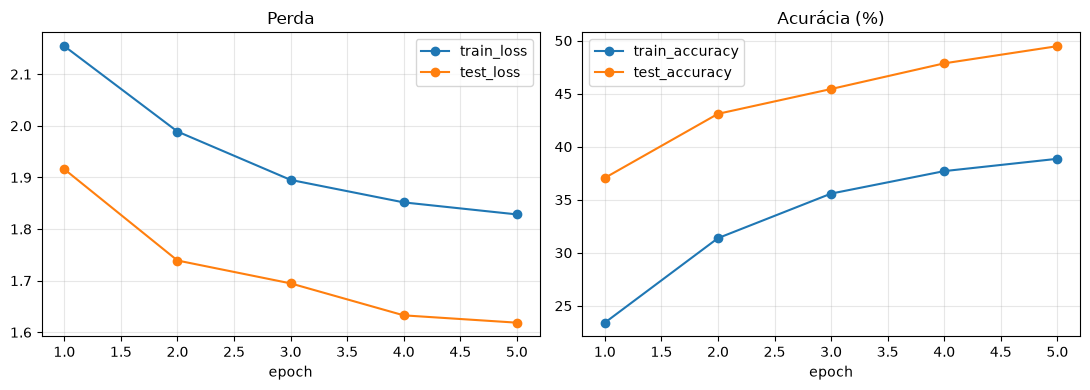

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history.plot(x="epoch", y=["train_loss", "test_loss"], marker="o", ax=axes[0], title="Perda")
history.plot(x="epoch", y=["train_accuracy", "test_accuracy"], marker="o", ax=axes[1], title="Acurácia (%)")
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Reparametrização estrutural

Durante o treinamento, cada `RepVGGDW` soma três caminhos: DW 3×3, DW 1×1 e identidade. Em avaliação, operações lineares e BatchNorm podem ser combinadas algebricamente em uma única DW 3×3. O teste abaixo exige que as saídas antes e depois da fusão sejam numericamente equivalentes.

In [27]:
checkpoint = OUTPUT_DIR / "repvit_m0_9_cifar10.pt"
model.load_state_dict(torch.load(checkpoint, map_location=DEVICE, weights_only=True))
model.eval()
deploy_model = reparameterize(copy.deepcopy(model)).to(DEVICE)
sample = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
with torch.inference_mode():
    reference = model(sample)
    deployed = deploy_model(sample)
max_difference = (reference - deployed).abs().max().item()
torch.testing.assert_close(deployed, reference, rtol=1e-3, atol=5e-3)
print(f"Diferença absoluta máxima: {max_difference:.2e}")

Diferença absoluta máxima: 2.39e-03


## 7. Benchmark de latência

A latência publicada usa Core ML, lote 1 e iPhone 12. Aqui medimos PyTorch no dispositivo exibido no início; portanto, compare as duas versões locais entre si, e não o valor absoluto com o artigo. Sincronização da GPU, aquecimento e percentis evitam uma média enganosa.

In [28]:
def synchronize():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


@torch.inference_mode()
def benchmark(model, warmup=30, runs=100):
    model.eval()
    image = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    for _ in range(warmup):
        model(image)
    synchronize()
    samples = []
    for _ in range(runs):
        start = time.perf_counter()
        model(image)
        synchronize()
        samples.append((time.perf_counter() - start) * 1_000)
    values = torch.tensor(samples)
    return {"mediana_ms": values.median().item(), "p90_ms": values.quantile(0.90).item()}


benchmark_results = pd.DataFrame([
    {"grafo": "treino (múltiplos ramos)", **benchmark(model)},
    {"grafo": "deploy (fundido)", **benchmark(deploy_model)},
])
benchmark_results["parâmetros_M"] = [
    sum(p.numel() for p in model.parameters()) / 1e6,
    sum(p.numel() for p in deploy_model.parameters()) / 1e6,
]
benchmark_results

,grafo,mediana_ms,p90_ms,parâmetros_M
0,treino (múltiplos ramos),6.321891,6.664695,4.722022
1,deploy (fundido),3.426021,3.543928,4.685518


## 8. Resultados publicados

Os próximos dados vêm das Tabelas 1 e 2 do PDF v8. Eles servem para reconstruir a fronteira acurácia–latência afirmada pelo artigo e não devem ser confundidos com medições deste notebook.

In [29]:
paper_results = pd.DataFrame({
    "modelo": ["RepViT-M0.9", "RepViT-M1.0", "RepViT-M1.1", "RepViT-M1.5", "RepViT-M2.3"],
    "parâmetros_M": [5.1, 6.8, 8.2, 14.0, 22.9],
    "GMACs": [0.8, 1.1, 1.3, 2.3, 4.5],
    "latência_iPhone12_ms": [0.9, 1.0, 1.1, 1.5, 2.3],
    "top1_sem_destilação": [77.4, 78.6, 79.4, 81.2, 83.3],
    "top1_com_destilação_450e": [79.1, 80.3, 81.2, 82.5, 83.7],
})
paper_results

,modelo,parâmetros_M,GMACs,latência_iPhone12_ms,top1_sem_destilação,top1_com_destilação_450e
0,RepViT-M0.9,5.1,0.8,0.9,77.4,79.1
1,RepViT-M1.0,6.8,1.1,1.0,78.6,80.3
2,RepViT-M1.1,8.2,1.3,1.1,79.4,81.2
3,RepViT-M1.5,14.0,2.3,1.5,81.2,82.5
4,RepViT-M2.3,22.9,4.5,2.3,83.3,83.7


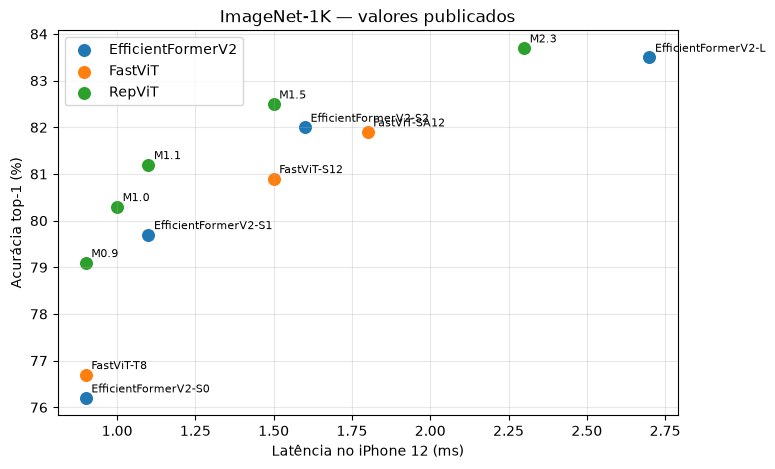

In [30]:
competitors = pd.DataFrame([
    ("FastViT-T8", "FastViT", 0.9, 76.7),
    ("EfficientFormerV2-S0", "EfficientFormerV2", 0.9, 76.2),
    ("EfficientFormerV2-S1", "EfficientFormerV2", 1.1, 79.7),
    ("FastViT-S12", "FastViT", 1.5, 80.9),
    ("EfficientFormerV2-S2", "EfficientFormerV2", 1.6, 82.0),
    ("FastViT-SA12", "FastViT", 1.8, 81.9),
    ("EfficientFormerV2-L", "EfficientFormerV2", 2.7, 83.5),
], columns=["modelo", "família", "latência_iPhone12_ms", "top1"])
comparison = pd.concat([
    paper_results.rename(columns={"top1_com_destilação_450e": "top1"})
        .assign(família="RepViT")[["modelo", "família", "latência_iPhone12_ms", "top1"]],
    competitors,
])
fig, ax = plt.subplots(figsize=(8, 5))
for family, group in comparison.groupby("família"):
    ax.scatter(group["latência_iPhone12_ms"], group["top1"], s=70, label=family)
for row in comparison.itertuples():
    ax.annotate(row.modelo.replace("RepViT-", ""), (row.latência_iPhone12_ms, row.top1), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_title("ImageNet-1K — valores publicados")
ax.set_xlabel("Latência no iPhone 12 (ms)")
ax.set_ylabel("Acurácia top-1 (%)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Modernização incremental da MobileNetV3-L

A Figura 2 do artigo acompanha cada decisão de projeto. A queda inicial ao separar os misturadores é recuperada pela menor expansão com maior largura; as decisões macro e micro levam ao RepViT-M0.9 final.

In [31]:
modernization = pd.DataFrame([
    ("MobileNetV3-L", 1.01, 71.5),
    ("separar misturadores", 0.81, 68.3),
    ("expansão 2 + largura", 0.89, 73.5),
    ("stem convolucional", 0.86, 73.9),
    ("downsampling profundo", 0.96, 75.4),
    ("classificador simples", 0.77, 74.8),
    ("razão de estágios", 0.91, 76.9),
    ("kernel 3×3", 0.89, 76.9),
    ("SE alternado (RepViT)", 0.87, 77.4),
], columns=["etapa", "latência_ms", "top1"])
modernization

,etapa,latência_ms,top1
0,MobileNetV3-L,1.01,71.5
1,separar misturadores,0.81,68.3
2,expansão 2 + largura,0.89,73.5
3,stem convolucional,0.86,73.9
4,downsampling profundo,0.96,75.4
5,classificador simples,0.77,74.8
6,razão de estágios,0.91,76.9
7,kernel 3×3,0.89,76.9
8,SE alternado (RepViT),0.87,77.4


### Ablações do artigo

A primeira tabela isola o efeito da reparametrização estrutural. A segunda mostra por que os autores adotam SE em blocos alternados: praticamente a mesma acurácia de SE em todos os blocos, com menor latência.

In [32]:
reparam_ablation = pd.DataFrame({
    "modelo": ["M0.9", "M1.5", "M2.3"],
    "top1_sem_reparam": [78.47, 82.09, 83.10],
    "top1_com_reparam": [78.74, 82.29, 83.30],
})
se_ablation = pd.DataFrame([
    ("M0.9", "sem SE", 77.92, 0.83), ("M0.9", "SE em todos", 78.75, 0.92), ("M0.9", "SE alternado", 78.74, 0.87),
    ("M1.5", "sem SE", 81.86, 1.48), ("M1.5", "SE em todos", 82.29, 1.58), ("M1.5", "SE alternado", 82.29, 1.52),
], columns=["modelo", "estratégia", "top1", "latência_ms"])
display(reparam_ablation)
display(se_ablation)

,modelo,top1_sem_reparam,top1_com_reparam
0,M0.9,78.47,78.74
1,M1.5,82.09,82.29
2,M2.3,83.10,83.30


,modelo,estratégia,top1,latência_ms
0,M0.9,sem SE,77.92,0.83
1,M0.9,SE em todos,78.75,0.92
2,M0.9,SE alternado,78.74,0.87
3,M1.5,sem SE,81.86,1.48
4,M1.5,SE em todos,82.29,1.58
5,M1.5,SE alternado,82.29,1.52


## 9. Registro do experimento

A última célula salva configuração, melhor acurácia local, erro da fusão e benchmark. Isso permite comparar execuções sem atribuir ao artigo números obtidos em outro conjunto ou hardware.

In [33]:
report = {
    "scope": "reprodução reduzida em CIFAR-10; não comparável diretamente ao ImageNet-1K",
    "device": DEVICE,
    "torch_version": torch.__version__,
    "config": config,
    "best_test_accuracy": best_accuracy,
    "fusion_max_absolute_difference": max_difference,
    "benchmark": benchmark_results.to_dict(orient="records"),
}
report_path = OUTPUT_DIR / "report.json"
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Relatório salvo em {report_path}")
report

Relatório salvo em /home/ribeiro.alvaro/Documentos/Mestrado/Repositories/alvaro-ribeiro-985-tp558/seminar2/notebooks/repvit_reproduction/report.json


{'scope': 'reprodução reduzida em CIFAR-10; não comparável diretamente ao ImageNet-1K',
 'device': 'cuda',
 'torch_version': '2.13.0+cu130',
 'config': {'fast_mode': True,
  'image_size': 224,
  'batch_size': 128,
  'epochs': 5,
  'train_samples': 10000,
  'test_samples': 5000,
  'learning_rate': 0.0003,
  'weight_decay': 0.05,
  'seed': 42},
 'best_test_accuracy': 49.48,
 'fusion_max_absolute_difference': 0.0023929402232170105,
 'benchmark': [{'grafo': 'treino (múltiplos ramos)',
   'mediana_ms': 6.321890830993652,
   'p90_ms': 6.6646952629089355,
   'parâmetros_M': 4.722022},
  {'grafo': 'deploy (fundido)',
   'mediana_ms': 3.426021099090576,
   'p90_ms': 3.5439281463623047,
   'parâmetros_M': 4.685518}]}

## Conclusão

O notebook reproduz os mecanismos arquiteturais que sustentam a proposta: uma CNN pura organizada como MetaFormer, expansão 2, separação das misturas espacial e de canais, SE alternado e reparametrização estrutural sem mudança significativa da saída. O experimento CIFAR-10 verifica que a implementação treina e permite observar a relação local entre acurácia e latência. A alegação quantitativa do artigo — mais de 80% top-1 em cerca de 1 ms — continua vinculada ao protocolo ImageNet-1K + Core ML + iPhone 12 dos autores.